## Monocular Metric Depth Estimation with ZoeDepth

This notebook evaluates the pretrained **ZoeDepth-NYU** monocular metric-depth model under a real indoor evaluation setup. In AI and robotics, monocular metric depth estimation provides geometric and spatial information from a single RGB camera, supporting applications such as robot navigation, obstacle detection, 3D scene understanding, and autonomous perception without requiring a dedicated depth sensor.

ZoeDepth-NYU is specialized for indoor metric-depth estimation, and is evaluated here against dense, per-pixel ground truth captured with a real Intel RealSense depth camera in an indoor lab environment.

The objective is to determine how accurately the pretrained model recovers physical scene depth from a single RGB image, using dense per-pixel comparison rather than a single manually measured distance per image.

The dataset consists of 59 synchronized RGB-depth pairs. The RGB image is the sole input to the model; the corresponding RealSense depth map is dense per-pixel ground truth used only for evaluation. Depth is stored in millimeters and converted to meters with a scale factor of 0.001. Zero-valued pixels are invalid and excluded from evaluation.

The primary evaluation metrics are:

* Mean Absolute Error (MAE)
* Root Mean Square Error (RMSE)
* Mean Absolute Relative Error (Abs Rel, %)
* Median depth error
* Predicted depth standard deviation
* Ground-truth and predicted median depth

## Experimental Setup

A RealSense RGB-D camera is used to capture synchronized RGB images and corresponding dense depth maps under a real indoor lab environment.

For each sample, the RGB image is provided to the monocular depth-estimation model, while the corresponding RealSense depth image is used as independent ground truth for evaluation only.

The depth images are stored as 16-bit PNG files with depth values in millimeters. For evaluation, these values are converted to meters using a scale factor of 0.001.

The dataset contains 59 corresponding RGB-depth pairs:

| Data                 | Samples |
| -------------------- | ------: |
| RGB images           |      59 |
| RealSense depth maps |      59 |
| RGB-depth pairs      |      59 |

The RealSense depth maps provide dense per-pixel ground truth rather than a single manually measured distance. This enables evaluation of both overall metric-depth accuracy and per-pixel spatial depth consistency.

The model receives **only the RGB image during inference**. The corresponding RealSense depth map is never provided to the model and is used exclusively as ground truth during evaluation.

In [ ]:
!pip install -q -U huggingface_hub transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 21.3 MB/s eta 0:00:00


In [ ]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import zipfile
import cv2
from PIL import Image
from huggingface_hub import hf_hub_download
from transformers import AutoImageProcessor, ZoeDepthForDepthEstimation, pipeline
from IPython.display import display

## Test Dataset

Each test sample contains:

* an RGB image captured by the RealSense camera
* a corresponding dense RealSense depth map
* depth values stored as 16-bit PNG values in millimeters
* depth ground truth converted from millimeters to meters using a scale factor of 0.001

The RGB image is used as the model input, while the corresponding RealSense depth map is used only for evaluation.

The 59 RGB-depth pairs are distributed as a single zip archive (`color/` and `depth/` subfolders, matched by filename) hosted on the Hugging Face dataset repo `WasiqSaleem/Portfolio_Assest`.

In [ ]:
HF_REPO = "WasiqSaleem/Portfolio_Assets"
HF_REPO_TYPE = "dataset"
ZIP_NAME = "testing_env_spec_real_camera_dataset_combined.zip"
DATASET_FOLDER = "testing_env_spec_real_camera_dataset_combined"  # top-level folder inside the zip
COLOR_SUBDIR = "color"
DEPTH_SUBDIR = "depth"

# RealSense depth PNGs are stored in millimeters -> convert to meters.
DEPTH_UNITS_TO_METERS = 0.001

In [ ]:
zip_path = hf_hub_download(
    repo_id=HF_REPO,
    filename=ZIP_NAME,
    repo_type=HF_REPO_TYPE,
    local_dir="/content"
)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall("/content")

dataset_root = Path("/content") / DATASET_FOLDER
color_dir = dataset_root / COLOR_SUBDIR
depth_dir = dataset_root / DEPTH_SUBDIR

color_files = sorted(color_dir.glob("*.png"))
depth_files = sorted(depth_dir.glob("*.png"))

assert len(color_files) == len(depth_files), (
    f"Mismatched counts: {len(color_files)} color vs {len(depth_files)} depth"
)

for c, d in zip(color_files, depth_files):
    assert c.stem == d.stem, f"Misaligned pair: {c.name} vs {d.name}"

print(f"Found {len(color_files)} aligned RGB-depth pairs.")

testing_env_spec_real_camera_dataset_com(…): reconstructing file:   0%|          |  0.00B / 26.9MB            

testing_env_spec_real_camera_dataset_com(…): downloading bytes:           |  0.00B            

Found 59 aligned RGB-depth pairs.


In [ ]:
available_cases = []

for color_path, depth_path in zip(color_files, depth_files):
    image = Image.open(color_path).convert("RGB")

    available_cases.append({
        "image_number": color_path.stem,
        "filename": color_path.name,
        "image_path": color_path,
        "depth_path": depth_path,
        "image": image
    })

print(f"Loaded {len(available_cases)} RGB-depth pairs.")

sample_depth_raw = np.array(Image.open(available_cases[0]["depth_path"]), dtype=np.float32)
sample_depth_m = sample_depth_raw * DEPTH_UNITS_TO_METERS
valid_sample = sample_depth_m[sample_depth_m > 0]

print(
    f"Sample frame '{available_cases[0]['image_number']}': "
    f"raw range [{sample_depth_raw.min():.0f}, {sample_depth_raw.max():.0f}] mm | "
    f"converted range [{valid_sample.min():.3f}, {valid_sample.max():.3f}] m"
)

Loaded 59 RGB-depth pairs.
Sample frame '00000': raw range [0, 6592] mm | converted range [1.514, 6.592] m


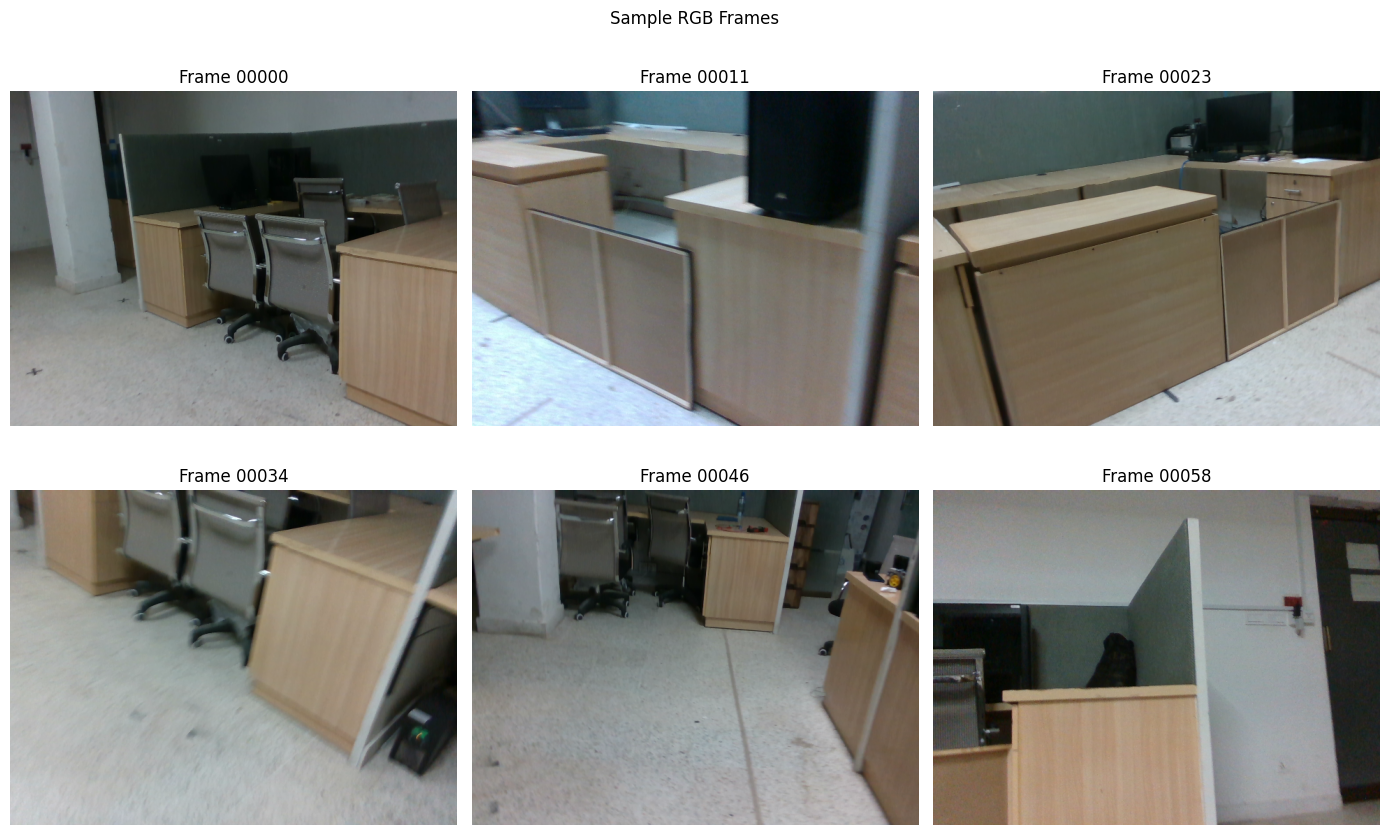

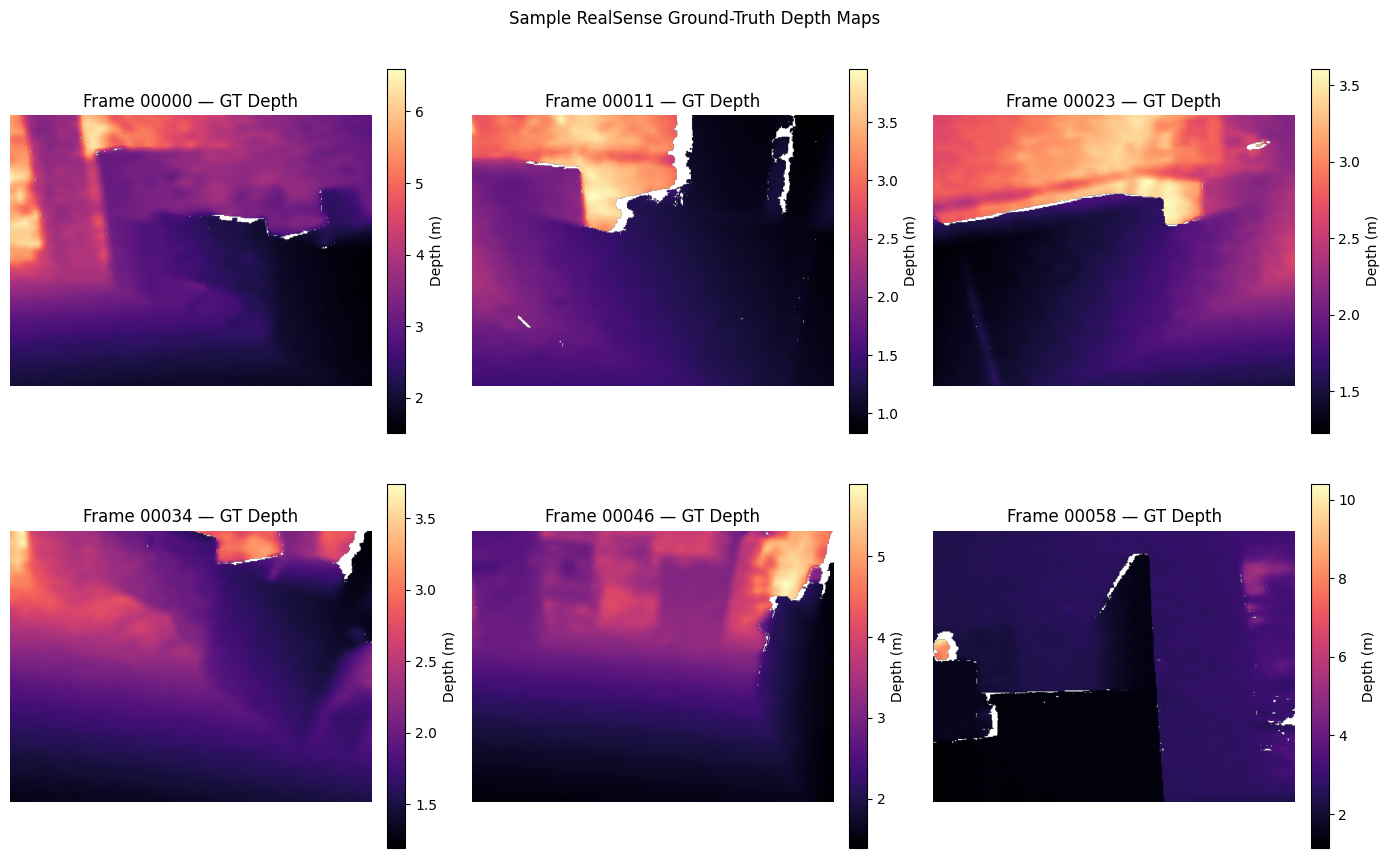

In [ ]:
sample_indices = np.linspace(0, len(available_cases) - 1, 6).astype(int)
sample_cases = [available_cases[i] for i in sample_indices]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, case in zip(axes.flat, sample_cases):
    ax.imshow(case["image"])
    ax.set_title(f"Frame {case['image_number']}")
    ax.axis("off")

plt.suptitle("Sample RGB Frames")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, case in zip(axes.flat, sample_cases):
    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    gt_display = np.ma.masked_where(gt_depth <= 0, gt_depth)

    im = ax.imshow(gt_display, cmap="magma")
    ax.set_title(f"Frame {case['image_number']} — GT Depth")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Depth (m)")

plt.suptitle("Sample RealSense Ground-Truth Depth Maps")
plt.tight_layout()
plt.show()

## Experimental Strategy & Evaluation Protocol

**Data collection.** RGB and depth frames are captured synchronously with an Intel RealSense depth camera in a real indoor lab environment, yielding 59 aligned RGB-depth pairs.

**Ground truth.** The RealSense depth map is dense, per-pixel ground truth. Stored 16-bit millimeter values are converted to meters using a scale factor of 0.001. Zero-valued pixels are invalid measurements and are excluded from every metric.

**Model input.** ZoeDepth-NYU receives only the RGB image. The RealSense depth map is never provided to the model and is used exclusively for evaluation.

**Prediction.** The model produces a dense metric depth map for each frame, resized to the ground-truth resolution when necessary.

**Comparison.** Prediction and ground truth are compared densely, pixel-by-pixel, over the valid overlapping pixels of each frame. The per-frame median depth is also retained as an image-level summary statistic alongside the dense pixel-level metrics.

In [ ]:
def evaluate_depth(depth_map, ground_truth):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)
    valid = (
        np.isfinite(depth_map) & np.isfinite(ground_truth)
        & (depth_map > 0) & (ground_truth > 0)
    )
    pred = depth_map[valid]
    gt = ground_truth[valid]
    if pred.size == 0:
        raise ValueError("No valid overlapping pixels between prediction and ground truth.")
    error = np.abs(pred - gt)
    return {
        "GT Median (m)": float(np.median(gt)),
        "Pred Median (m)": float(np.median(pred)),
        "Pred Mean (m)": float(np.mean(pred)),
        "Std Depth (m)": float(np.std(pred)),
        "MAE (m)": float(np.mean(error)),
        "RMSE (m)": float(np.sqrt(np.mean((pred - gt) ** 2))),
        "Abs Rel (%)": float(np.mean(error / gt) * 100),
        "Median Absolute Error (m)": float(np.median(error)),
        "Valid Pixels (%)": float(valid.mean() * 100),
    }

## ZoeDepth-NYU

ZoeDepth-NYU is specialized for indoor metric-depth estimation.

The model receives only the RGB image. The RealSense ground-truth depth map is not supplied during inference.

The predicted dense depth map is then compared, pixel-by-pixel, against the dense RealSense ground-truth depth map for the same frame.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nyu_model_id = "Intel/zoedepth-nyu"

nyu_processor = AutoImageProcessor.from_pretrained(nyu_model_id)
nyu_model = ZoeDepthForDepthEstimation.from_pretrained(
    nyu_model_id
).to(device).eval()

print(f"Using device: {device}")
print("ZoeDepth-NYU loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.38GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/553 [00:00<?, ?it/s]

Using device: cuda
ZoeDepth-NYU loaded successfully.


In [ ]:
nyu_results = []
nyu_depth_maps = {}

for case in available_cases:
    inputs = nyu_processor(
        images=case["image"],
        return_tensors="pt"
    )
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = nyu_model(**inputs)

    image_size = (case["image"].height, case["image"].width)
    processed = nyu_processor.post_process_depth_estimation(
        outputs,
        source_sizes=[image_size],
        target_sizes=[image_size]
    )

    depth_map = (
        processed[0]["predicted_depth"]
        .squeeze()
        .cpu()
        .numpy()
    )

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS

    if depth_map.shape != gt_depth.shape:
        depth_map = cv2.resize(
            depth_map,
            (gt_depth.shape[1], gt_depth.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )

    metrics = evaluate_depth(depth_map, gt_depth)

    result = {
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Model": "ZoeDepth-NYU",
        **metrics
    }

    nyu_results.append(result)
    nyu_depth_maps[case["image_number"]] = depth_map

nyu_df = pd.DataFrame(nyu_results)

display(nyu_df)

,Image,Filename,Model,GT Median (m),Pred Median (m),Pred Mean (m),Std Depth (m),MAE (m),RMSE (m),Abs Rel (%),Median Absolute Error (m),Valid Pixels (%)
0,00000,00000.png,ZoeDepth-NYU,2.933,3.215477,3.275339,1.072827,0.286650,0.340501,9.530751,0.265780,99.714518
1,00001,00001.png,ZoeDepth-NYU,2.229,2.749858,2.743232,1.032808,0.577903,0.724988,22.929134,0.487772,99.284831
2,00002,00002.png,ZoeDepth-NYU,1.318,1.840924,1.766282,0.597194,0.412158,0.507398,29.918688,0.479104,97.738932
3,00003,00003.png,ZoeDepth-NYU,1.419,1.784844,1.820556,0.605457,0.382895,0.424533,27.437384,0.382378,97.826823
4,00004,00004.png,ZoeDepth-NYU,1.378,1.803570,2.069520,1.062579,0.501100,0.584969,31.432560,0.435415,97.052734
5,00005,00005.png,ZoeDepth-NYU,1.368,1.888170,2.032600,1.148572,0.516136,0.615013,32.459106,0.512340,96.108073
6,00006,00006.png,ZoeDepth-NYU,1.708,2.213157,2.415963,0.664808,0.530104,0.540755,31.170750,0.520902,94.202474
7,00007,00007.png,ZoeDepth-NYU,1.442,1.780213,1.867651,0.910894,0.270921,0.304758,17.400679,0.282498,97.359049
8,00008,00008.png,ZoeDepth-NYU,1.922,2.169721,2.278084,0.539288,0.261692,0.283132,15.651854,0.274171,92.944987
9,00009,00009.png,ZoeDepth-NYU,1.618,1.967562,2.114213,0.389009,0.361611,0.373673,21.114992,0.362089,99.040039


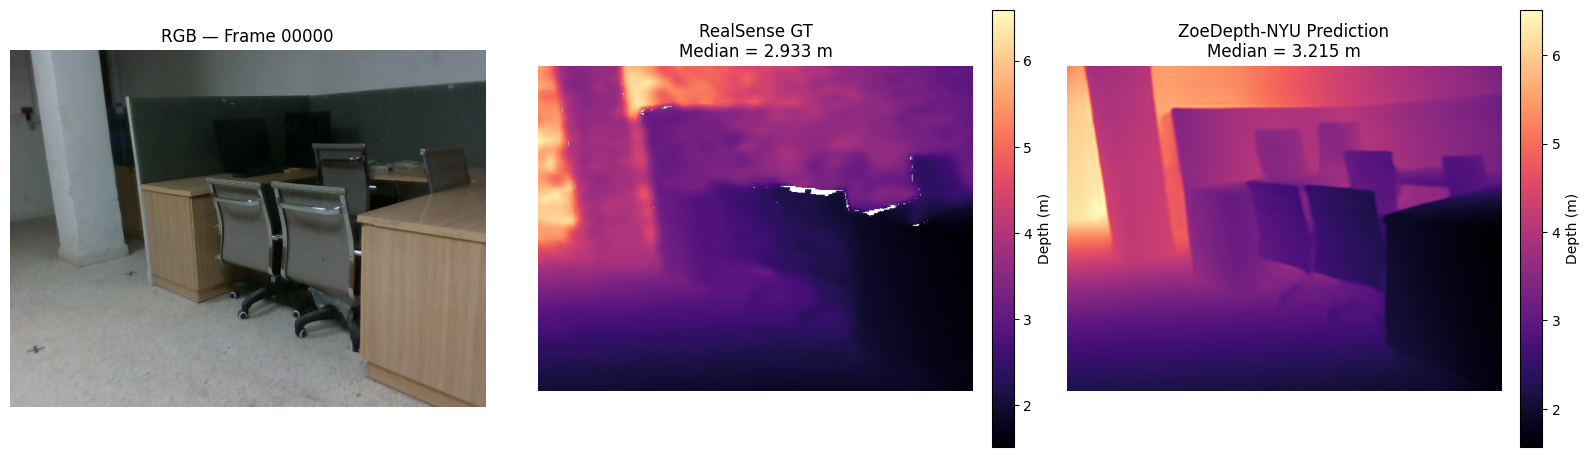

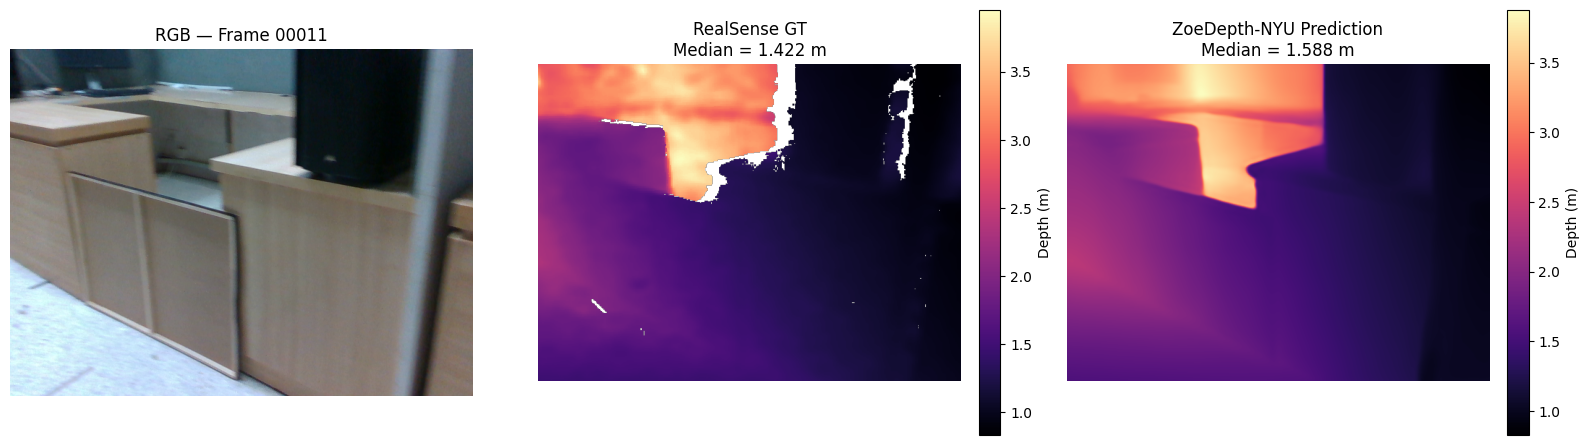

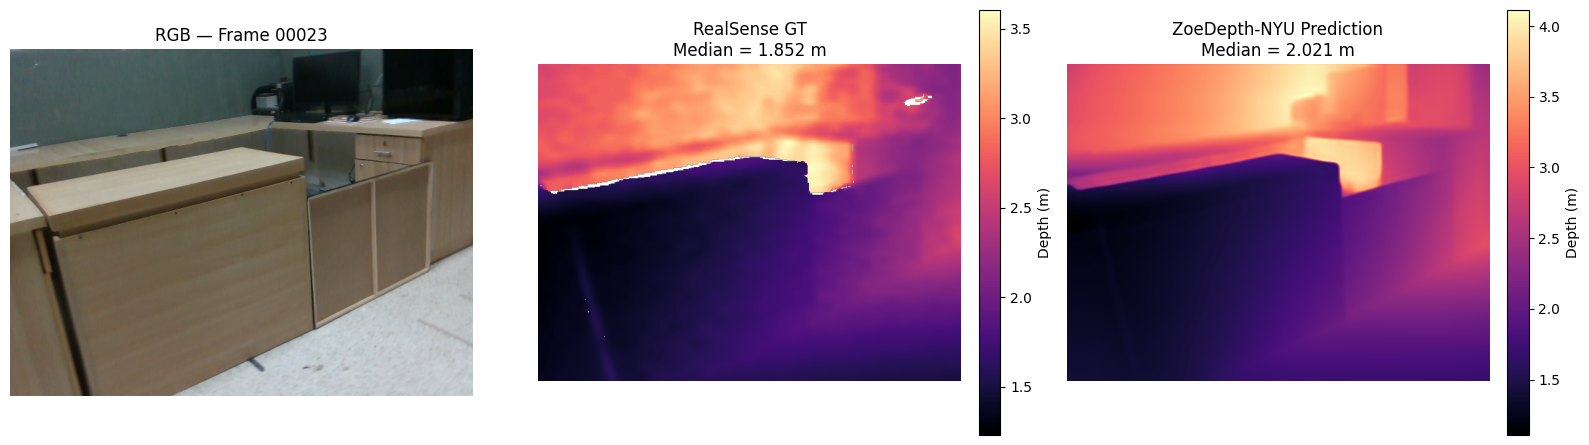

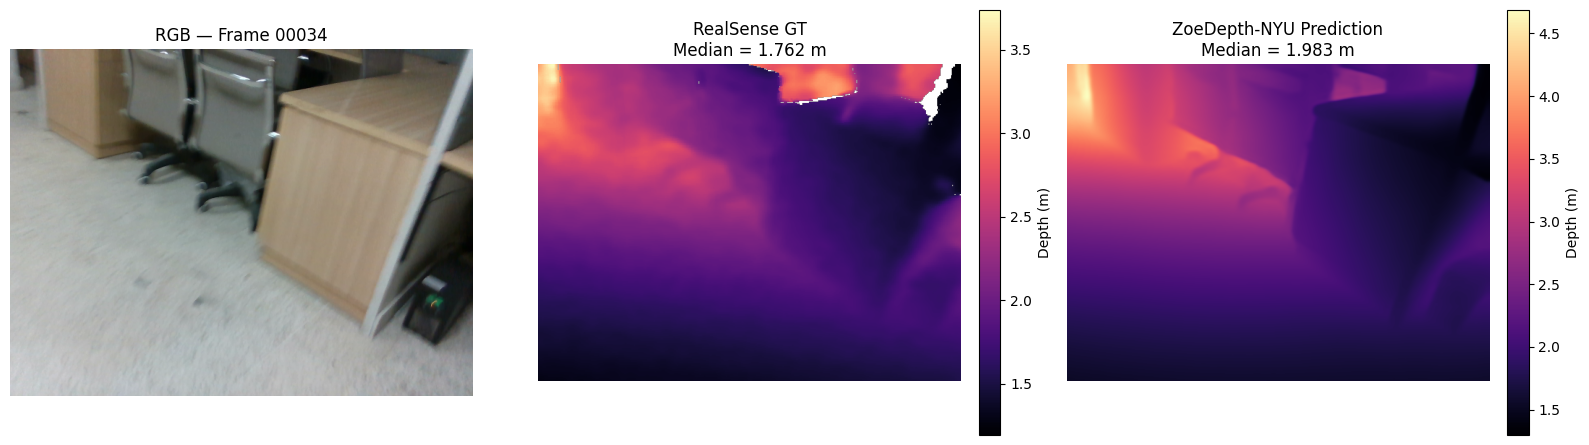

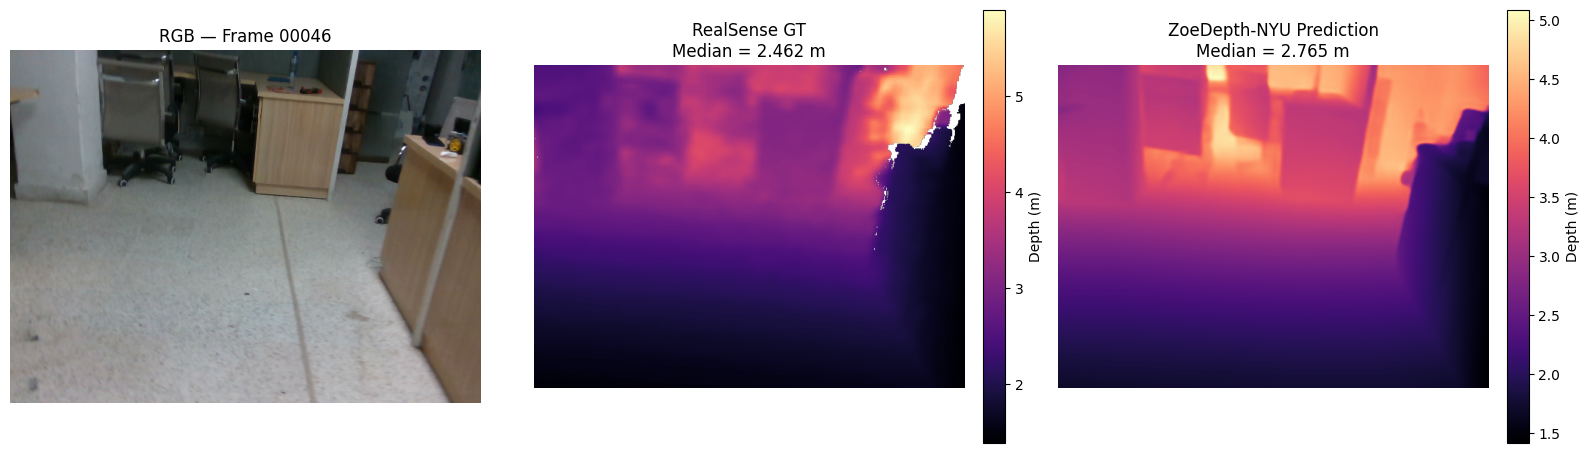

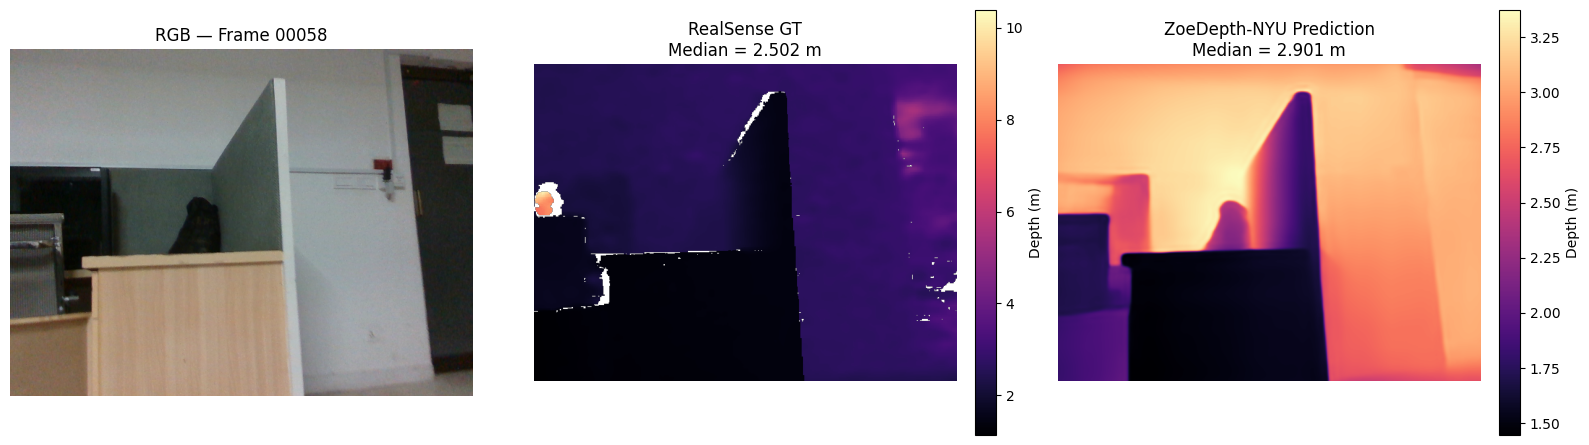

In [ ]:
qual_indices = np.linspace(0, len(available_cases) - 1, 6).astype(int)

for idx in qual_indices:
    case = available_cases[idx]
    depth_map = nyu_depth_maps[case["image_number"]]
    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    gt_display = np.ma.masked_where(gt_depth <= 0, gt_depth)

    result = nyu_df[nyu_df["Image"] == case["image_number"]].iloc[0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(case["image"])
    axes[0].set_title(f"RGB — Frame {case['image_number']}")
    axes[0].axis("off")

    im1 = axes[1].imshow(gt_display, cmap="magma")
    axes[1].set_title(f"RealSense GT\nMedian = {result['GT Median (m)']:.3f} m")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Depth (m)")

    im2 = axes[2].imshow(depth_map, cmap="magma")
    axes[2].set_title(f"ZoeDepth-NYU Prediction\nMedian = {result['Pred Median (m)']:.3f} m")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="Depth (m)")

    plt.tight_layout()
    plt.show()

## Results Summary

ZoeDepth-NYU is evaluated densely, per-pixel, against the RealSense ground-truth depth map for every one of the 59 frames.

Each frame yields dense pixel-level metrics (MAE, RMSE, Abs Rel, median absolute error) alongside image-level summary statistics (ground-truth median depth, predicted median depth, predicted depth standard deviation).

These per-frame results are then aggregated across the full dataset to produce an overall accuracy summary.

In [ ]:
results_df = nyu_df.copy()

display(
    results_df[[
        "Image", "Model", "GT Median (m)", "Pred Median (m)",
        "Std Depth (m)", "MAE (m)", "RMSE (m)", "Abs Rel (%)",
        "Median Absolute Error (m)", "Valid Pixels (%)"
    ]]
)

overall_summary = (
    results_df
    .groupby("Model")
    .agg(
        Samples=("Model", "size"),
        MAE_m=("MAE (m)", "mean"),
        RMSE_m=("RMSE (m)", "mean"),
        Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Median_Error_m=("Median Absolute Error (m)", "mean"),
        Mean_Surface_Std_m=("Std Depth (m)", "mean")
    )
    .reset_index()
)

display(overall_summary)

,Image,Model,GT Median (m),Pred Median (m),Std Depth (m),MAE (m),RMSE (m),Abs Rel (%),Median Absolute Error (m),Valid Pixels (%)
0,00000,ZoeDepth-NYU,2.933,3.215477,1.072827,0.286650,0.340501,9.530751,0.265780,99.714518
1,00001,ZoeDepth-NYU,2.229,2.749858,1.032808,0.577903,0.724988,22.929134,0.487772,99.284831
2,00002,ZoeDepth-NYU,1.318,1.840924,0.597194,0.412158,0.507398,29.918688,0.479104,97.738932
3,00003,ZoeDepth-NYU,1.419,1.784844,0.605457,0.382895,0.424533,27.437384,0.382378,97.826823
4,00004,ZoeDepth-NYU,1.378,1.803570,1.062579,0.501100,0.584969,31.432560,0.435415,97.052734
5,00005,ZoeDepth-NYU,1.368,1.888170,1.148572,0.516136,0.615013,32.459106,0.512340,96.108073
6,00006,ZoeDepth-NYU,1.708,2.213157,0.664808,0.530104,0.540755,31.170750,0.520902,94.202474
7,00007,ZoeDepth-NYU,1.442,1.780213,0.910894,0.270921,0.304758,17.400679,0.282498,97.359049
8,00008,ZoeDepth-NYU,1.922,2.169721,0.539288,0.261692,0.283132,15.651854,0.274171,92.944987
9,00009,ZoeDepth-NYU,1.618,1.967562,0.389009,0.361611,0.373673,21.114992,0.362089,99.040039


,Model,Samples,MAE_m,RMSE_m,Abs_Rel_pct,Median_Error_m,Mean_Surface_Std_m
0,ZoeDepth-NYU,59,0.360469,0.429678,17.247632,0.325535,0.766591


## Predicted Depth vs Ground Truth

The ideal metric-depth model follows:

**Predicted Depth = Ground-Truth Depth**

The closer the per-frame points are to this identity relationship, the better the metric-depth accuracy across the dataset.

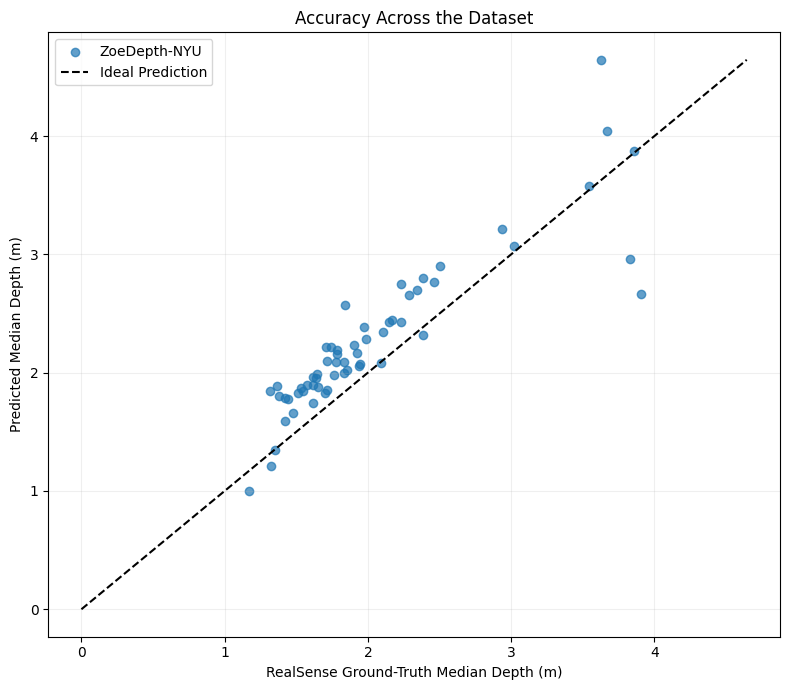

In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    results_df["GT Median (m)"],
    results_df["Pred Median (m)"],
    alpha=0.7,
    label="ZoeDepth-NYU"
)

max_value = max(
    results_df["GT Median (m)"].max(),
    results_df["Pred Median (m)"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    color="black",
    label="Ideal Prediction"
)

plt.xlabel("RealSense Ground-Truth Median Depth (m)")
plt.ylabel("Predicted Median Depth (m)")
plt.title("Accuracy Across the Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

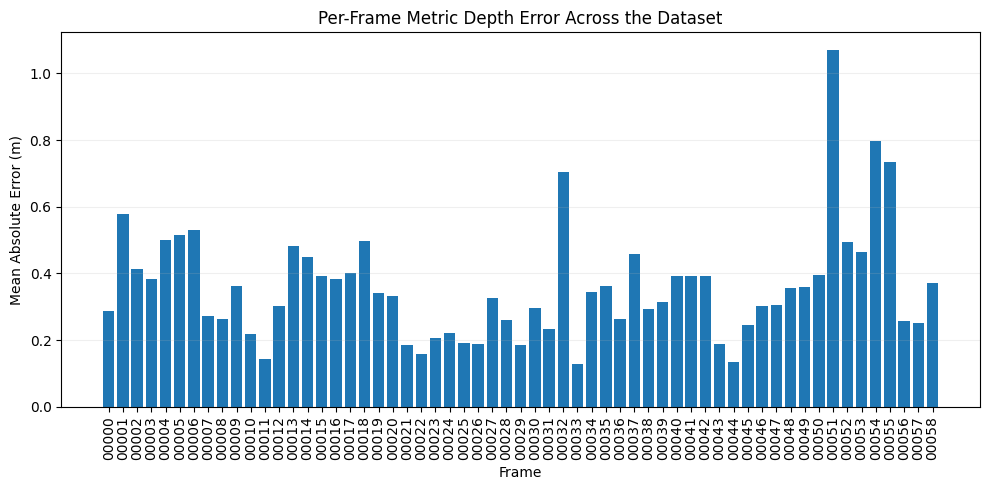

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Image"], results_df["MAE (m)"])

plt.xlabel("Frame")
plt.ylabel("Mean Absolute Error (m)")
plt.title("Per-Frame Metric Depth Error Across the Dataset")
plt.xticks(rotation=90)
plt.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

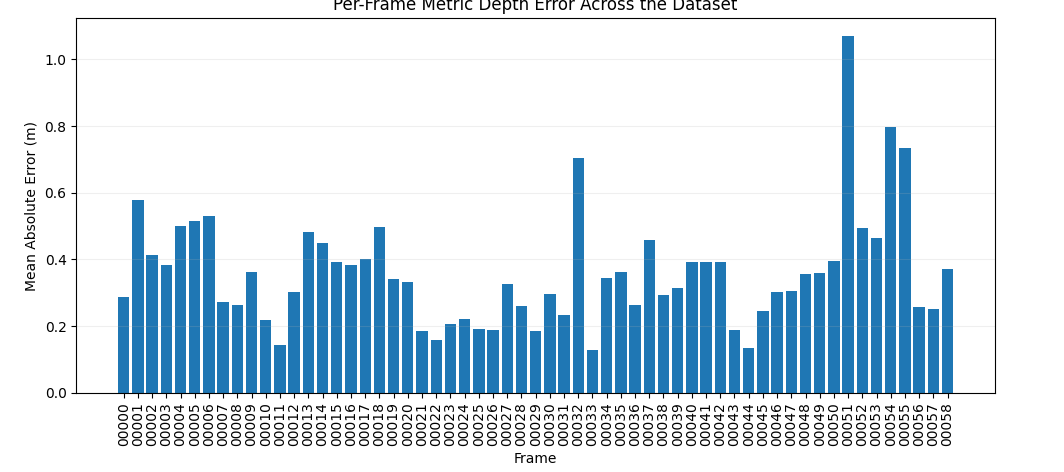

## Depth Distribution

For each sampled frame, the predicted depth pixels are compared against the distribution of valid RealSense ground-truth depth pixels.

Unlike a single scalar ground-truth value, the RealSense depth map provides a full distribution of true depths across the scene, so ground truth is shown here as a histogram rather than a vertical reference line.

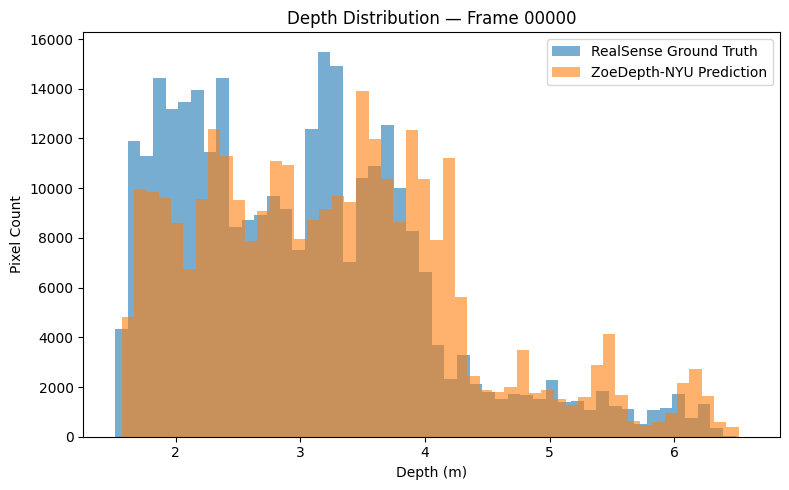

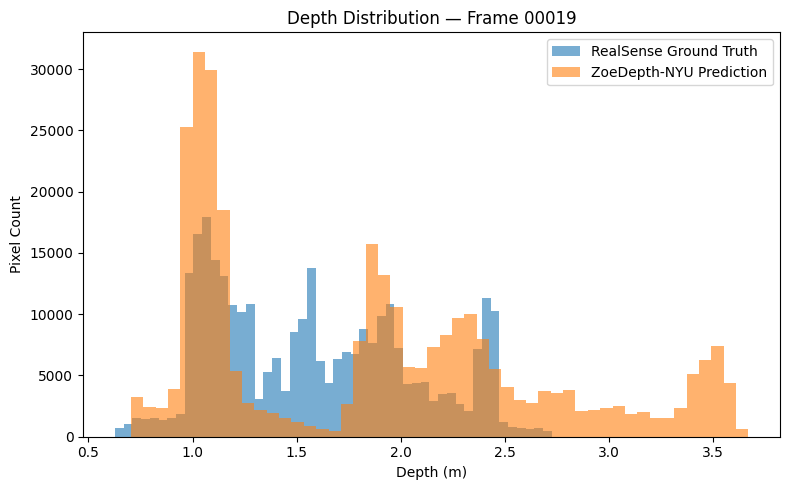

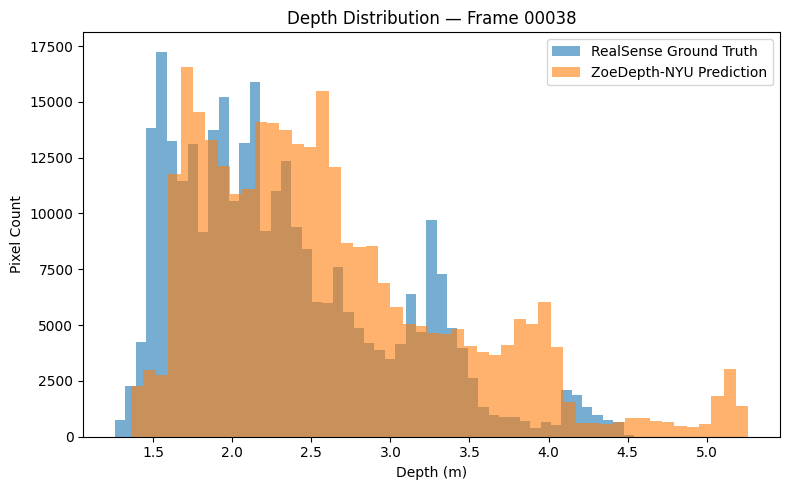

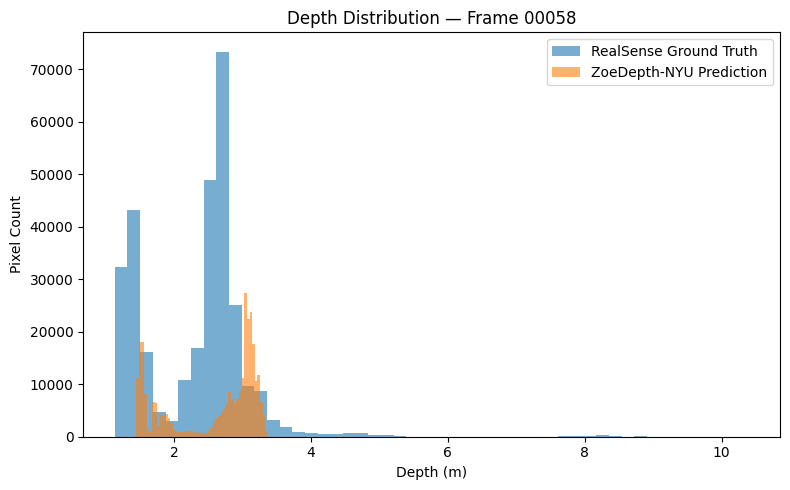

In [ ]:
dist_indices = np.linspace(0, len(available_cases) - 1, 4).astype(int)

for idx in dist_indices:
    case = available_cases[idx]
    depth_map = nyu_depth_maps[case["image_number"]]

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    valid_gt = gt_depth[gt_depth > 0]

    plt.figure(figsize=(8, 5))
    plt.hist(valid_gt.flatten(), bins=50, alpha=0.6, label="RealSense Ground Truth")
    plt.hist(depth_map.flatten(), bins=50, alpha=0.6, label="ZoeDepth-NYU Prediction")

    plt.xlabel("Depth (m)")
    plt.ylabel("Pixel Count")
    plt.title(f"Depth Distribution — Frame {case['image_number']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Simplified Hugging Face Pipeline

The pipeline API provides a convenient interface for rapid prototyping.

It is kept separate from the quantitative evaluation because the explicit model API above provides direct access to the metric depth tensor required for numerical evaluation.

In [ ]:
depth_pipeline = pipeline(
    task="depth-estimation",
    model=nyu_model_id,
    device=0 if torch.cuda.is_available() else -1
)

Loading weights:   0%|          | 0/553 [00:00<?, ?it/s]

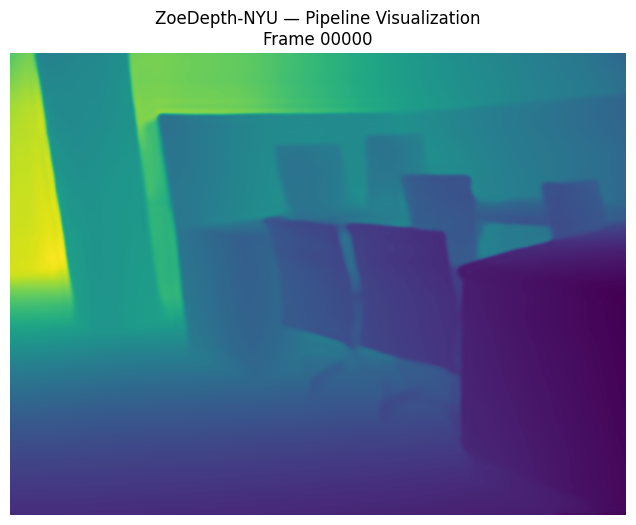

In [ ]:
example_case = available_cases[0]

pipeline_output = depth_pipeline(
    example_case["image"]
)

depth_visual = pipeline_output["depth"]

plt.figure(figsize=(8, 6))
plt.imshow(depth_visual)
plt.title(
    f"ZoeDepth-NYU — Pipeline Visualization\n"
    f"Frame {example_case['image_number']}"
)
plt.axis("off")
plt.show()

## Interpretation

The per-frame error plot shows that Depth Pro's metric-depth accuracy varies considerably across different frames. Most frames exhibit an absolute depth error between approximately 0.15 m and 0.50 m, indicating generally acceptable depth estimation, while a smaller number of frames show substantially higher errors.

The lowest errors occur in frames such as 00011, 00023–00026, 00044, and 00058, where the MAE is approximately 0.13–0.20 m. This indicates that Depth Pro performs relatively well for scenes with favorable visual characteristics and clear depth cues.

In contrast, several frames show significant error peaks. The most prominent error occurs at frame 00051, with an MAE of approximately 1.07 m. Other high-error frames include 00032 (~0.70 m), 00055 (~0.74 m), and 00052 (~0.49 m). These large deviations indicate that Depth Pro's performance is not uniform and that certain scene configurations are considerably more difficult for the model.

An important observation is that the majority of frames remain below approximately 0.5 m MAE, while only a few frames produce errors above 0.7 m. This suggests that the overall performance is influenced disproportionately by a small number of difficult frames. This also explains why the overall RMSE (0.316 m) is higher than the typical median absolute error (0.144 m) shown in the summary table.

The variation between frames can potentially be associated with scene depth, surface characteristics, texture, lighting, and challenging visual structures. However, the experiment itself does not establish which of these factors caused the individual peaks. The evaluation notes specifically identify reflective, transparent, distant, and low-texture surfaces as conditions that can degrade the RealSense reference depth, while accurate RGB-depth alignment is also required for reliable pixel-level evaluation.

## Limitations

This experiment evaluates a single pretrained indoor metric-depth model against real dense ground truth, rather than an established public benchmark. The main limitations are:

1. The RealSense sensor itself may introduce noise, or produce invalid/zero-valued pixels on reflective, transparent, distant, or low-texture surfaces.
2. The dataset is limited to a single indoor lab environment.
3. Only 59 RGB-depth pairs are evaluated, which limits statistical power.
4. RGB-depth alignment must be accurate for the pixel-level metrics to be meaningful; any registration error between the RGB and depth streams will appear as depth error.
5. Only the indoor-specialized ZoeDepth-NYU model is evaluated here; results should not be generalized to mixed indoor/outdoor scenes.
6. Established datasets such as NYUv2 provide more comprehensive benchmark evaluations across many more scenes and conditions.

The experiment is therefore intended to investigate pretrained model behavior under a real but limited indoor capture setup, rather than replace established depth benchmarks.

## Conclusion

This experiment establishes a pipeline for evaluating monocular metric-depth estimation from RGB images against real, dense per-pixel ground truth.

The workflow is:

**RealSense RGB-depth capture → RGB image → pretrained ZoeDepth-NYU model → dense depth prediction → dense pixel-level comparison against RealSense ground truth → statistical analysis → quantitative error evaluation**

Evaluating 59 real RGB-depth pairs from a single indoor lab environment enables both pixel-level and image-level (median-depth) accuracy analysis for the ZoeDepth-NYU model.

The same protocol is a reproducible foundation that can be extended to additional scenes, capture environments, and other monocular depth models.